# CLASSIFICATIE

In [8]:
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split




## TRAIN TEST SET

In [9]:
df_all = pd.read_csv('goedeoutput.csv')
df_all = df_all.drop_duplicates(subset='file')
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.575868,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.916088,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.862473,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.736694,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434


In [10]:
colomn_names = df_all.columns
colomn_names

# colomnen verwijderen
feature_names=['time', 'x', 'y', 'z', 'abs', 'weight', 'weather',
       'x_std', 'z_std', 'x_mean',
       'x_rms', 'z_rms',
       'z_spectral_flatness']
Y = df_all['roadtype']
X = df_all[feature_names]
X = pd.get_dummies(X, columns=['weather'], drop_first=True, dtype=int)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X.head()

,time,x,y,z,abs,weight,x_std,z_std,x_mean,x_rms,z_rms,z_spectral_flatness,weather_Dry,weather_Wet
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,0.0,0.373276,0.140477,0.067120,0.377403,0.139825,0.653138,1,0
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,0.0,2.181070,0.575868,-0.722286,2.287180,0.579284,0.574400,1,0
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,0.0,2.370932,0.916088,0.911198,2.528798,0.927195,0.745212,1,0
298,3.000444,3.016697,0.947292,-0.673180,3.232800,0.0,3.425790,0.862473,-0.349491,3.426488,0.860367,0.702190,1,0
398,4.005364,-0.492856,1.994679,0.532708,2.122600,0.0,2.177802,0.736694,0.466448,2.216413,0.740745,0.828434,1,0


## neuraal netwerk

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=5000,
        solver="lbfgs",
        random_state=42
    ))
])

# Grid
param_grid = {
    "mlp__hidden_layer_sizes": [
        (10,),
        (20,),
        (20, 10),
        (30, 15),
        (50, 25)
    ],
    "mlp__activation": [
        "tanh",
        "relu"
    ],
    "mlp__alpha": [
        0.00001,
        0.0001,
        0.001,
        0.01
    ]
}

# Grid Search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

# Beste model
best_model = grid.best_estimator_

print("Beste parameters:")
print(grid.best_params_)
print("\nBeste CV-score:")
print(grid.best_score_)

# Testset voorspellingen
pred = best_model.predict(x_test)

print("\nTest Accuracy:")
print(accuracy_score(y_test, pred))

# Resultaten per klasse
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

correct_counts = (
    results[results["Actual"] == results["Predicted"]]
    .groupby("Actual")
    .size()
)

print("\nCorrect voorspeld per klasse:")
print(correct_counts)

percentages = (
    correct_counts /
    results["Actual"].value_counts() * 100
)

print("\nPercentage correct per klasse:")
print(percentages)

Beste parameters:
{'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (50, 25)}

Beste CV-score:
0.6700564971751412

Test Accuracy:
0.6306306306306306

Correct voorspeld per klasse:
Actual
asphalt    34
bricks     23
grass      48
gravel     15
sand       11
wood        9
dtype: int64

Percentage correct per klasse:
Actual
asphalt    57.627119
bricks     42.592593
grass      84.210526
gravel     68.181818
sand       84.615385
wood       52.941176
dtype: float64


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(20, 10),
        activation="tanh",
        solver="lbfgs",        # veel beter voor kleine datasets
        alpha=0.0001,
        max_iter=5000,
        random_state=42
    ))
])

model.fit(x_train, y_train)
pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred))

results = pd.DataFrame({'Actual': y_test, 'Predicted': pred})

correct_counts = results[results['Actual'] == results['Predicted']] \
                    .groupby('Actual') \
                    .size()

print(correct_counts)

percentages = correct_counts / results['Actual'].value_counts() * 100
print(percentages)




Accuracy: 0.5765765765765766
Actual
asphalt    28
bricks     25
grass      43
gravel     13
sand       12
wood        7
dtype: int64
Actual
asphalt    47.457627
bricks     46.296296
grass      75.438596
gravel     59.090909
sand       92.307692
wood       41.176471
dtype: float64


In [12]:
model.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('mlp',
   MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 10), max_iter=5000,
                 random_state=42, solver='lbfgs'))],
 'verbose': False,
 'scaler': StandardScaler(),
 'mlp': MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 10), max_iter=5000,
               random_state=42, solver='lbfgs'),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'mlp__activation': 'tanh',
 'mlp__alpha': 0.0001,
 'mlp__batch_size': 'auto',
 'mlp__beta_1': 0.9,
 'mlp__beta_2': 0.999,
 'mlp__early_stopping': False,
 'mlp__epsilon': 1e-08,
 'mlp__hidden_layer_sizes': (20, 10),
 'mlp__learning_rate': 'constant',
 'mlp__learning_rate_init': 0.001,
 'mlp__max_fun': 15000,
 'mlp__max_iter': 5000,
 'mlp__momentum': 0.9,
 'mlp__n_iter_no_change': 10,
 'mlp__nesterovs_momentum': True,
 'mlp__power_t': 0.5,
 'mlp__random_state': 42,
 'mlp__shuffle': True,
 'mlp__solver': 'lbfgs',
 'mlp__tol': 0.0001,
 

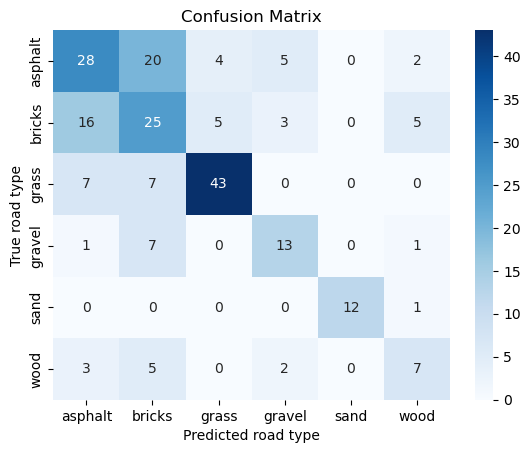

In [13]:
class_names = ['asphalt', 'bricks', 'grass', 'gravel', 'sand', 'wood']
conf_matrix = confusion_matrix(y_test,pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",xticklabels=class_names,
    yticklabels=class_names)

plt.xlabel("Predicted road type")
plt.ylabel("True road type")
plt.title("Confusion Matrix")
plt.show()

## model

In [14]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)
classifier = RandomForestClassifier(n_estimators=100, random_state=12)
classifier.fit(x_train_scale, y_train)
y_pred = classifier.predict(x_test_scale)
ac = accuracy_score(y_test,y_pred)

print(f'de accuracy is {ac}')

de accuracy is 0.7252252252252253


In [15]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

correct_counts = results[results['Actual'] == results['Predicted']] \
                    .groupby('Actual') \
                    .size()

print(correct_counts)

percentages = correct_counts / results['Actual'].value_counts() * 100
print(percentages)

Actual
asphalt    40
bricks     33
grass      53
gravel     13
sand       13
wood        9
dtype: int64
Actual
asphalt     67.796610
bricks      61.111111
grass       92.982456
gravel      59.090909
sand       100.000000
wood        52.941176
dtype: float64


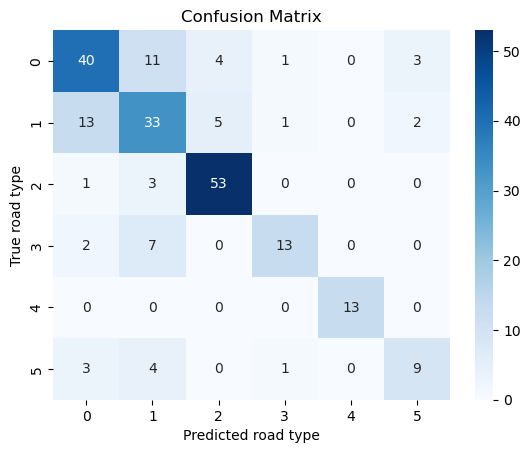

In [16]:
conf_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted road type")
plt.ylabel("True road type")
plt.title("Confusion Matrix")
plt.show()

## met gridsearch

LET OP! gridsearch duurt 145 minuten

In [17]:
pipeline = make_pipeline(StandardScaler(), RandomForestClassifier()) #max_iter=1000, tol=1e-3))

param_grid = {
    'randomforestclassifier__n_estimators': [300, 500, 800],
    'randomforestclassifier__max_depth': [10, 20, 40, None],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    'randomforestclassifier__criterion': ['gini', 'entropy']
}




grid_cv = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=1, 
                       cv=7, 
                       verbose=2) 

grid_cv.fit(x_train, y_train)

Fitting 7 folds for each of 432 candidates, totalling 3024 fits
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.9s
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.9s
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.9s
[CV] END randomforestclassifier__criterion=gini, randomforestclassifier__max_depth=10, randomfor

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=1,
             param_grid={'randomforestclassifier__criterion': ['gini',
                                                               'entropy'],
                         'randomforestclassifier__max_depth': [10, 20, 40,
                                                               None],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [300, 500,
                                                                  800]},
             verbose=2)

In [20]:
print(f'For the training set, using K-fold CV the best estimator is: {grid_cv.best_estimator_}')
print(f'Leading to an accuracy of: {grid_cv.best_score_}')
y_pred = grid_cv.best_estimator_.predict(x_test)
ass = accuracy_score(y_test,y_pred)
print(f'de accuracy score is {ass}')

For the training set, using K-fold CV the best estimator is: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(criterion='entropy', max_depth=40,
                                        min_samples_split=5,
                                        n_estimators=500))])
Leading to an accuracy of: 0.7130180156051923
de accuracy score is 0.7387387387387387


{'randomforestclassifier__criterion': 'entropy',
 'randomforestclassifier__max_depth': 40,
 'randomforestclassifier__max_features': 'sqrt',
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__n_estimators': 500}

In [21]:
grid_cv.best_params_

{'randomforestclassifier__criterion': 'entropy',
 'randomforestclassifier__max_depth': 40,
 'randomforestclassifier__max_features': 'sqrt',
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__n_estimators': 500}

In [19]:
param_grid = {
    'randomforestclassifier__n_estimators': [300, 500],
    'randomforestclassifier__max_depth': [20, None],
    'randomforestclassifier__min_samples_split': [2, 5],
    'randomforestclassifier__min_samples_leaf': [1, 2],
    'randomforestclassifier__max_features': ['sqrt']
}

grid_cv_simpel = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=1, 
                       cv=7, 
                       verbose=2) 

grid_cv_simpel.fit(x_train, y_train)

Fitting 7 folds for each of 16 candidates, totalling 112 fits
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.4s
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.4s
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=300; total time=   0.4s
[CV] END randomforestclassifier__max_depth=20, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_leaf=1, randomforestclassifier__min_samples_split=2, randomforestclassifier__n_estimators=30

KeyboardInterrupt: 

In [ ]:
print(f'For the training set, using K-fold CV the best estimator is: {grid_cv_simpel.best_estimator_}')
print(f'Leading to an accuracy of: {grid_cv_simpel.best_score_}')
y_pred_simpel = grid_cv_simpel.best_estimator_.predict(x_test)
ass = accuracy_score(y_test,y_pred_simpel)
print(f'de accuracy score is {ass}')

For the training set, using K-fold CV the best estimator is: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=20, n_estimators=500))])
Leading to an accuracy of: 0.7096255825164712
de accuracy score is 0.7072072072072072


In [22]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

correct_counts = results[results['Actual'] == results['Predicted']] \
                    .groupby('Actual') \
                    .size()

print(correct_counts)

percentages = correct_counts / results['Actual'].value_counts() * 100
print(percentages)

Actual
asphalt    41
bricks     34
grass      54
gravel     12
sand       13
wood       10
dtype: int64
Actual
asphalt     69.491525
bricks      62.962963
grass       94.736842
gravel      54.545455
sand       100.000000
wood        58.823529
dtype: float64


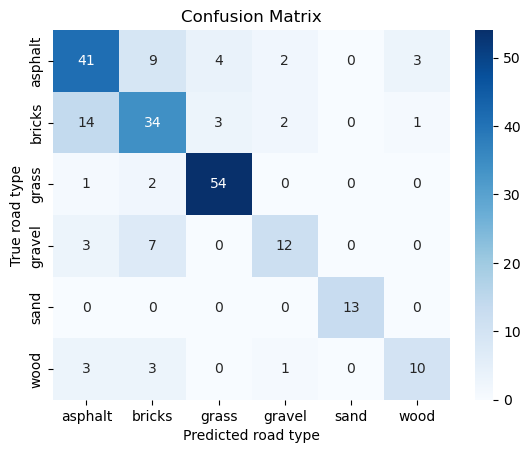

In [24]:
class_names = ['asphalt', 'bricks', 'grass', 'gravel', 'sand', 'wood']
conf_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",xticklabels=class_names,
    yticklabels=class_names)

plt.xlabel("Predicted road type")
plt.ylabel("True road type")
plt.title("Confusion Matrix")
plt.show()

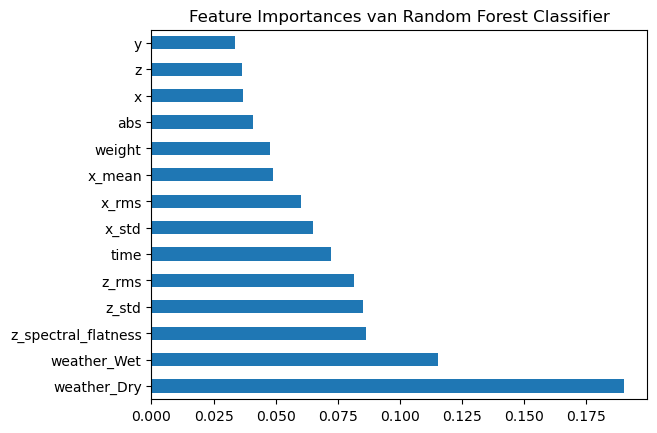

In [26]:
best_rf = grid_cv.best_estimator_.named_steps['randomforestclassifier']

feat_importances = pd.Series(
    best_rf.feature_importances_,
    index=x_train.columns
)

feat_importances.nlargest(20).plot(kind='barh')
plt.title('Feature Importances van Random Forest Classifier')
plt.show()

## DOCUMENTATIE

https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/